# Get an EM image

In [2]:
# Add auto reload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from fafbseg import flywire
from decouple import config, Config, RepositoryEnv

ENV_PATH = "../.env"

### Load in token ###
# return client
config = Config(RepositoryEnv(ENV_PATH))
# Get the FLYWIRE_AUTH_TOKEN
flywire_token = config("FLYWIRE_AUTH_TOKEN", default=None)

#Save the secret
flywire.set_chunkedgraph_secret(flywire_token)


FLYWIRE_AUTH_TOKEN: 408d8f3e74ec253fab7b770f4863d5fb


Neuron skeleton: type              navis.TreeNeuron
name                      skeleton
id              720575940624928574
n_nodes                       3692
n_connectors                  None
n_branches                     515
n_leafs                        538
cable_length             1840787.5
soma            [3297, 3306, 3320]
units                  1 nanometer
dtype: object


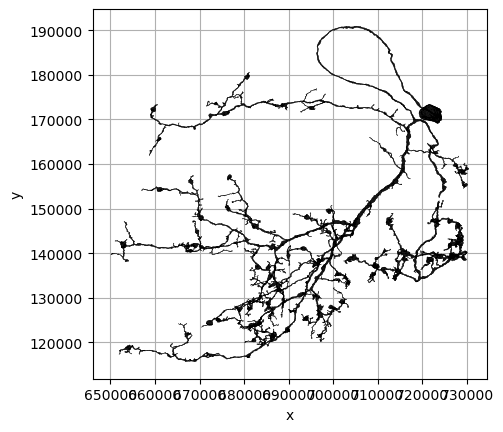

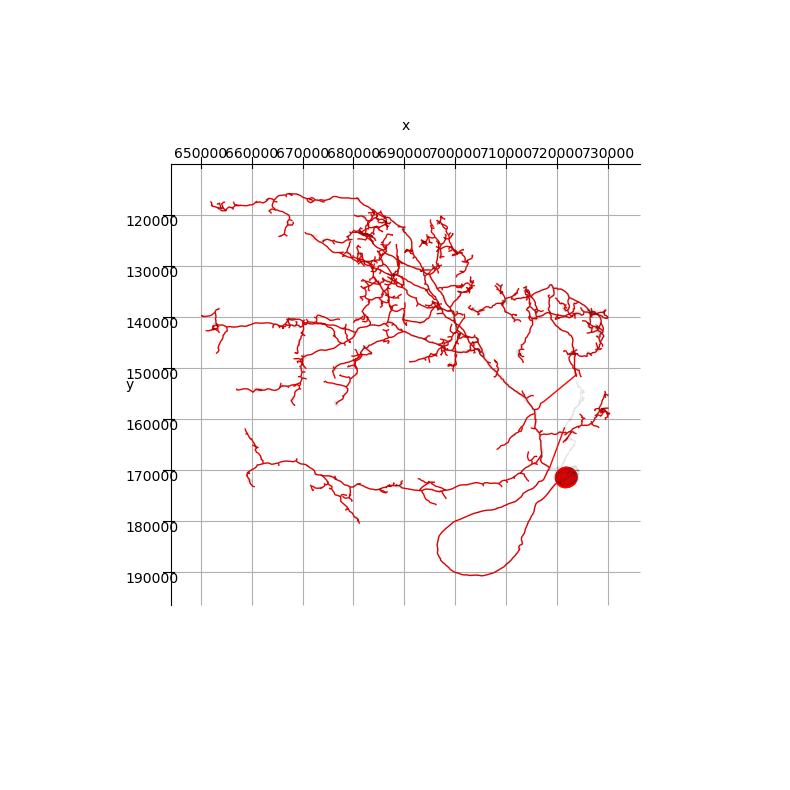

In [19]:
import navis
from fafbseg import flywire
root_id = "720575940624928574"

# latest_root = flywire.is_latest_root(root_id)
# print(f"Latest root ID: {latest_root}")

# Neuron Mesh
neuron_mesh = flywire.get_mesh_neuron(root_id)
fig, ax = navis.plot2d(neuron_mesh, color='k')

# Neuron Skeleton
neuron_skeleton = flywire.get_skeletons(root_id)
print(f"Neuron skeleton: {neuron_skeleton}")

fig, ax = navis.plot2d([neuron_skeleton, neuron_mesh], color=["r", (.3, .3, .3, 0.1)], figsize=(10, 10), method='3d_complex')
ax.azim = ax.elev = -90

In [ ]:
supervoxel = "82192342869822207"
test_url = flywire.encode_url(segments=[root_id])
print(f"Encoded URL: {test_url}")

Encoded URL: https://ngl.flywire.ai/?json_url=https://globalv1.flywire-daf.com/nglstate/5049750322675712


In [22]:
from fafbseg import flywire
root_id = "720575940624928574"
result = flywire.get_voxels(root_id, dataset="public")
print(f"Root ID: {root_id}")
print(f"Voxel: {result}")

SSLError: HTTPSConnectionPool(host='seungdata.princeton.edu', port=443): Max retries exceeded with url: /sseung-archive/fafbv14-ws/ws_190410_FAFB_v02_ws_size_threshold_200/info (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1010)')))

In [11]:
import inspect
options = inspect.getmembers(flywire, inspect.isfunction)
print(f"Available functions in flywire module: {len(options)}")
for name, func in options:
    print(f"Function name: {name}")
    print(f"Function docstring: {func.__doc__}")
    print(f"Function signature: {inspect.signature(func)}")
    print("-" * 40)

Available functions in flywire module: 54
Function name: create_cave_table
Function docstring: Create CAVE annotation table.

    This is just a thin-wrapper around `CAVEclient.annotation.create_table`.

    Note that newly created tables will not show up as materialized until the
    next round of materialization. Unfortuntately, there is currently no way to
    query un-materialized tables.

    Existing tables can be browsed
    `here <https://prod.flywire-daf.com/annotation/views/aligned_volume/fafb_seung_alignment_v0>`_.

    Parameters
    ----------
    name :              str
                        Name of the table.
    schema :            str
                        Name of the schema. This determines what data we can put
                        in the table. Here are some useful ones:

                         - "bound_tag" contains a location ("pt") and a text
                           "tag"
                         - "contact" contains two locations ("sidea_pt" and
     